# USGS Earthquake Catalog Analysis

Note: What each column header means can be found [here](https://earthquake.usgs.gov/earthquakes/feed/v1.0/csv.php).

## Data Processing

In [24]:
# All libraries needed for data exploration
import pandas as pd
from datetime import datetime
import string
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [25]:
# The dataframe that contains the earthquake data
df = pd.read_csv("query.csv")
df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-29T00:41:14.360Z,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,...,2026-02-17T23:14:25.095Z,"15 km NNW of Susanville, CA",earthquake,0.250000,0.72000,NaN,95.0,reviewed,nc,nc
1,2025-12-28T19:02:07.730Z,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,...,2026-01-19T21:20:01.040Z,"39 km E of Lee Vining, CA",earthquake,0.200000,0.66000,0.186000,36.0,reviewed,nc,nc
2,2025-12-28T17:47:09.990Z,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,...,2026-02-12T20:26:14.260Z,"11 km ENE of Lancaster, Kentucky",earthquake,0.410000,2.29000,0.022049,12.0,reviewed,se,se
3,2025-12-27T15:20:28.858Z,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,...,2026-01-20T22:57:55.205Z,"21 km NNE of Yerington, Nevada",earthquake,NaN,1.16400,NaN,NaN,reviewed,nn,nn
4,2025-12-27T01:00:26.055Z,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,...,2026-01-19T23:03:44.040Z,"12 km NNW of Kermit, Texas",earthquake,0.961404,2.87351,0.200000,53.0,reviewed,tx,tx


In [26]:
# To display the number of rows and columns
num_rows = len(df)
num_cols = len(df.columns)

print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 12899
Number of columns: 22


In [27]:
# To get all the column names and their types
df.dtypes

time                object
latitude           float64
longitude          float64
depth              float64
mag                float64
magType             object
nst                float64
gap                float64
dmin               float64
rms                float64
net                 object
id                  object
updated             object
place               object
type                object
horizontalError    float64
depthError         float64
magError           float64
magNst             float64
status              object
locationSource      object
magSource           object
dtype: object

In [28]:
# To see if there's any missing data in the dataset
total_non_mising = df.count()
total_non_mising

time               12899
latitude           12899
longitude          12899
depth              12899
mag                12899
magType            12898
nst                 7964
gap                12746
dmin               10926
rms                12896
net                12899
id                 12899
updated            12899
place              12899
type               12899
horizontalError    11548
depthError         12896
magError            9845
magNst             11208
status             12899
locationSource     12899
magSource          12899
dtype: int64

In [29]:
# To see if columns that should not have a duplicate has a duplicate value
for col in df.columns:
  print(f"Column: {col}, Duplicates: {df[col].duplicated().sum()}")

Column: time, Duplicates: 0
Column: latitude, Duplicates: 1502
Column: longitude, Duplicates: 1285
Column: depth, Duplicates: 8883
Column: mag, Duplicates: 12657
Column: magType, Duplicates: 12885
Column: nst, Duplicates: 12674
Column: gap, Duplicates: 11557
Column: dmin, Duplicates: 7391
Column: rms, Duplicates: 11960
Column: net, Duplicates: 12886
Column: id, Duplicates: 0
Column: updated, Duplicates: 2929
Column: place, Duplicates: 6750
Column: type, Duplicates: 12891
Column: horizontalError, Duplicates: 11249
Column: depthError, Duplicates: 10968
Column: magError, Duplicates: 12356
Column: magNst, Duplicates: 12546
Column: status, Duplicates: 12896
Column: locationSource, Duplicates: 12881
Column: magSource, Duplicates: 12878


# Cleaning Data Section

In [30]:
# To fix the time and updated columns to represent in datetime format
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df["updated"] = pd.to_datetime(df["updated"], errors="coerce")

df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-29 00:41:14.360000+00:00,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,...,2026-02-17 23:14:25.095000+00:00,"15 km NNW of Susanville, CA",earthquake,0.250000,0.72000,NaN,95.0,reviewed,nc,nc
1,2025-12-28 19:02:07.730000+00:00,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,...,2026-01-19 21:20:01.040000+00:00,"39 km E of Lee Vining, CA",earthquake,0.200000,0.66000,0.186000,36.0,reviewed,nc,nc
2,2025-12-28 17:47:09.990000+00:00,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,...,2026-02-12 20:26:14.260000+00:00,"11 km ENE of Lancaster, Kentucky",earthquake,0.410000,2.29000,0.022049,12.0,reviewed,se,se
3,2025-12-27 15:20:28.858000+00:00,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,...,2026-01-20 22:57:55.205000+00:00,"21 km NNE of Yerington, Nevada",earthquake,NaN,1.16400,NaN,NaN,reviewed,nn,nn
4,2025-12-27 01:00:26.055000+00:00,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,...,2026-01-19 23:03:44.040000+00:00,"12 km NNW of Kermit, Texas",earthquake,0.961404,2.87351,0.200000,53.0,reviewed,tx,tx


In [31]:
# Separate the time by year, month, day, and hour
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["hour"] = df["time"].dt.hour

df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,depthError,magError,magNst,status,locationSource,magSource,year,month,day,hour
0,2025-12-29 00:41:14.360000+00:00,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,...,0.72000,NaN,95.0,reviewed,nc,nc,2025,12,29,0
1,2025-12-28 19:02:07.730000+00:00,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,...,0.66000,0.186000,36.0,reviewed,nc,nc,2025,12,28,19
2,2025-12-28 17:47:09.990000+00:00,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,...,2.29000,0.022049,12.0,reviewed,se,se,2025,12,28,17
3,2025-12-27 15:20:28.858000+00:00,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,...,1.16400,NaN,NaN,reviewed,nn,nn,2025,12,27,15
4,2025-12-27 01:00:26.055000+00:00,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,...,2.87351,0.200000,53.0,reviewed,tx,tx,2025,12,27,1


In [32]:
# To check all columns that have missing values
df.isnull().sum()

time                  0
latitude              0
longitude             0
depth                 0
mag                   0
magType               1
nst                4935
gap                 153
dmin               1973
rms                   3
net                   0
id                    0
updated               0
place                 0
type                  0
horizontalError    1351
depthError            3
magError           3054
magNst             1691
status                0
locationSource        0
magSource             0
year                  0
month                 0
day                   0
hour                  0
dtype: int64

In [33]:
# To drop and replace all missing columns with the mean

# Drop the missing values in least important areas
df.dropna(subset=["magType", "rms", "depthError"], inplace=True)

df["nst"] = df["nst"].fillna(df["nst"].mean())
df["gap"] = df["gap"].fillna(df["gap"].mean())
df["dmin"] = df["dmin"].fillna(df["dmin"].mean())
df["horizontalError"] = df["horizontalError"].fillna(df["horizontalError"].mean())
df["magError"] = df["magError"].fillna(df["magError"].mean())
df["magNst"] = df["magNst"].fillna(df["magNst"].mean())

df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,depthError,magError,magNst,status,locationSource,magSource,year,month,day,hour
0,2025-12-29 00:41:14.360000+00:00,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,...,0.72000,0.137858,95.00000,reviewed,nc,nc,2025,12,29,0
1,2025-12-28 19:02:07.730000+00:00,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,...,0.66000,0.186000,36.00000,reviewed,nc,nc,2025,12,28,19
2,2025-12-28 17:47:09.990000+00:00,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,...,2.29000,0.022049,12.00000,reviewed,se,se,2025,12,28,17
3,2025-12-27 15:20:28.858000+00:00,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,...,1.16400,0.137858,54.32197,reviewed,nn,nn,2025,12,27,15
4,2025-12-27 01:00:26.055000+00:00,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,...,2.87351,0.200000,53.00000,reviewed,tx,tx,2025,12,27,1


In [34]:
# To check all columns that have missing values after replacing
df.isnull().sum()

time               0
latitude           0
longitude          0
depth              0
mag                0
magType            0
nst                0
gap                0
dmin               0
rms                0
net                0
id                 0
updated            0
place              0
type               0
horizontalError    0
depthError         0
magError           0
magNst             0
status             0
locationSource     0
magSource          0
year               0
month              0
day                0
hour               0
dtype: int64

In [35]:
# To filter the dataset to only contain earthquakes
df = df[df["type"] == "earthquake"]
df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,depthError,magError,magNst,status,locationSource,magSource,year,month,day,hour
0,2025-12-29 00:41:14.360000+00:00,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,...,0.72000,0.137858,95.00000,reviewed,nc,nc,2025,12,29,0
1,2025-12-28 19:02:07.730000+00:00,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,...,0.66000,0.186000,36.00000,reviewed,nc,nc,2025,12,28,19
2,2025-12-28 17:47:09.990000+00:00,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,...,2.29000,0.022049,12.00000,reviewed,se,se,2025,12,28,17
3,2025-12-27 15:20:28.858000+00:00,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,...,1.16400,0.137858,54.32197,reviewed,nn,nn,2025,12,27,15
4,2025-12-27 01:00:26.055000+00:00,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,...,2.87351,0.200000,53.00000,reviewed,tx,tx,2025,12,27,1


In [36]:
# Remove outliers
df = df[(df['horizontalError'] < 99) & (df['depthError'] < 30)]
df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,depthError,magError,magNst,status,locationSource,magSource,year,month,day,hour
0,2025-12-29 00:41:14.360000+00:00,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,...,0.72000,0.137858,95.00000,reviewed,nc,nc,2025,12,29,0
1,2025-12-28 19:02:07.730000+00:00,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,...,0.66000,0.186000,36.00000,reviewed,nc,nc,2025,12,28,19
2,2025-12-28 17:47:09.990000+00:00,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,...,2.29000,0.022049,12.00000,reviewed,se,se,2025,12,28,17
3,2025-12-27 15:20:28.858000+00:00,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,...,1.16400,0.137858,54.32197,reviewed,nn,nn,2025,12,27,15
4,2025-12-27 01:00:26.055000+00:00,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,...,2.87351,0.200000,53.00000,reviewed,tx,tx,2025,12,27,1


# Data Exploration

## Correlation


In [37]:
# Correlation between earthquake depth and magnitude
display(df[['depth', 'mag']].corr(method='pearson'))

# Correlation between # of stations calculating magnitude and magnitude error
display(df[['magNst', 'magError']].corr(method='pearson'))

# Correlation between # of stations calculating location and horizontal/depth error
display(df[['nst', 'horizontalError', 'depthError']].corr(method='pearson'))

# Correlation between # of stations for location and measures of proximity (dmin, gap)
display(df[['nst', 'dmin', 'gap']].corr(method='pearson'))

# Correlation between # of stations for location and RMS (measure of arrival time accuracy)
display(df[['nst', 'rms']].corr(method='pearson'))

# Correlation between horizontal/depth error and RMS
display(df[['horizontalError', 'depthError', 'rms']].corr(method='pearson'))

# Correlation between all types of error
display(df[['horizontalError', 'depthError', 'magError']].corr(method='pearson'))

# Correlation between crowd-sourced DFYI intensity

,depth,mag
depth,1.000000,0.098935
mag,0.098935,1.000000


,magNst,magError
magNst,1.000000,-0.194684
magError,-0.194684,1.000000


,nst,horizontalError,depthError
nst,1.000000,-0.188134,-0.175140
horizontalError,-0.188134,1.000000,0.486452
depthError,-0.175140,0.486452,1.000000


,nst,dmin,gap
nst,1.000000,-0.096894,-0.342647
dmin,-0.096894,1.000000,0.256105
gap,-0.342647,0.256105,1.000000


,nst,rms
nst,1.000000,-0.007233
rms,-0.007233,1.000000


,horizontalError,depthError,rms
horizontalError,1.000000,0.486452,0.649065
depthError,0.486452,1.000000,0.490913
rms,0.649065,0.490913,1.000000


,horizontalError,depthError,magError
horizontalError,1.000000,0.486452,-0.123467
depthError,0.486452,1.000000,-0.166985
magError,-0.123467,-0.166985,1.000000


Most quantitative features do not appear to be strongly correlated. The notable pairs that are mostly strongly correlated (all positively) are horizontal error & RMS, depth error & RMS, horizontal & depth error. It makes sense that a higher error, which indicates an inaccurate location, would be correlated with less accurate predicted arrival times. It also makes sense that higher errors in both depth and horizontal position would be correlated with each other. Below is a scatter plot of horizontal error vs RMS.

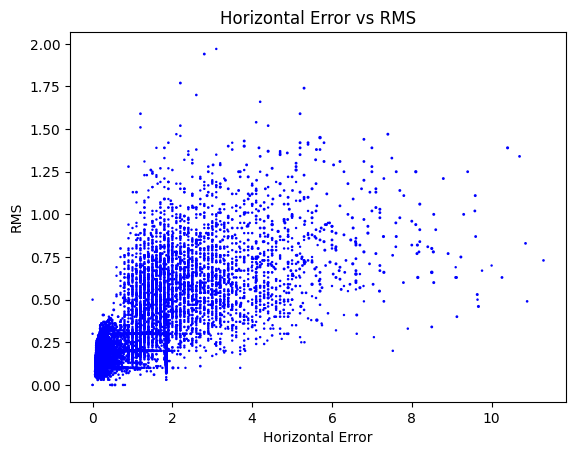

In [38]:
# Scatter plot for horizontal error vs RMS with dots scaled to magnitude
plt.scatter(x=df['horizontalError'], y=df['rms'], s=df['mag'], c='Blue', linewidths=0)

# Labels and title
plt.title('Horizontal Error vs RMS')
plt.xlabel('Horizontal Error')
plt.ylabel('RMS')

# Display plot
plt.show()

## Seasonal Effect on Earthquake Magnitude

For this portion of the data exploration, I will analyze whether the season of the year affects the mean magnitude of earthquakes.

### Hypothesis:
Null Hypothesis (Ho): The season of the year does not have an effect on the magnitude mean of an earthquake.

Alternative Hypothesis (Ha): The season of the year does have an effect on the magnitude mean of an earthquake.

In [39]:
# To map the seasons into a new column for easier analysis
seasons = {
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall",
    12: "Winter"
}

# To create the season column
df["season"] = df["month"].map(seasons)

# To separate the seasons and retrieve the magnitudes
winter = df[df["season"] == "Winter"]["mag"]
spring = df[df["season"] == "Spring"]["mag"]
summer = df[df["season"] == "Summer"]["mag"]
fall   = df[df["season"] == "Fall"]["mag"]

# I will use One-Way ANOVA for this test since we are comparing the magnitude means of the seasons
anova = stats.f_oneway(winter, spring, summer, fall)
p_value = anova.pvalue

print(f"The p value: {str(p_value)}")

# This is to determine whether to reject or fail to reject the null hypothesis
# The signifiance level will be at 0.05 default
a = 0.05
if p_value <= a:
  print("Reject the null hypothesis")
else:
  print("Fail to reject the null hypothesis")

The p value: 0.027869199105697313
Reject the null hypothesis


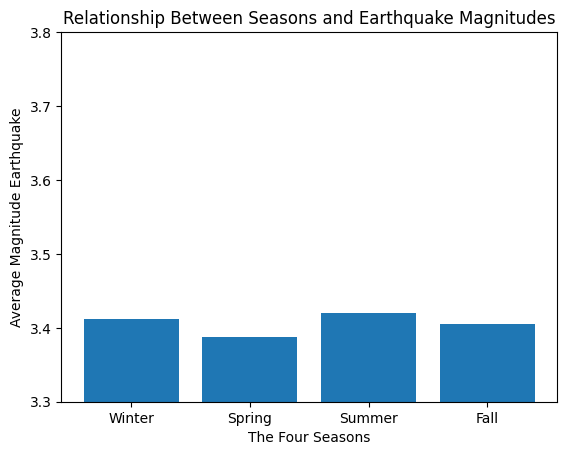

Winter Mean: 3.4113420889705766
Spring Mean: 3.3874941121397426
Summer Mean: 3.4200658925210927
Fall Mean: 3.4046235003585528


In [40]:
# To create a bar graph that has the seasons magnitudes for earthquakes
plt.bar(["Winter", "Spring", "Summer", "Fall"], [winter.mean(), spring.mean(), summer.mean(), fall.mean()])

# To add labels
plt.xlabel("The Four Seasons")
plt.ylabel("Average Magnitude Earthquake")
plt.ylim(3.3, 3.8)
plt.title("Relationship Between Seasons and Earthquake Magnitudes")

# Display plot
plt.show()

# To retrieve the exact values
print(f"Winter Mean: {winter.mean()}")
print(f"Spring Mean: {spring.mean()}")
print(f"Summer Mean: {summer.mean()}")
print(f"Fall Mean: {fall.mean()}")

Observations: Based on the hypothesis, we must reject the null hypothesis because the p-value is less than the significance level (α = 0.05). That means there's evidence in the dataset that the earthquake magnitude differs across seasons, as indicated by the one-way ANOVA. From the graph, we can see that the magnitude of earthquakes is higher during the summer, while spring earthquakes usually have a lower magnitude. The higher earthquake magnitudes in the summer can likely stem from environmental changes, but the averages across seasons mainly remain around 3.3 to 3.4.

### Post Hoc Test

In [41]:
# To run a Tukey's HSD Post Hoc Test since we are looking for the specific
# pairwise group that differs from the ANOVA test
tukey_hsd_result = stats.tukey_hsd(winter, spring, summer, fall)

print(tukey_hsd_result)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.024     0.192    -0.007     0.055
 (0 - 2)     -0.009     0.865    -0.038     0.020
 (0 - 3)      0.007     0.947    -0.025     0.038
 (1 - 0)     -0.024     0.192    -0.055     0.007
 (1 - 2)     -0.033     0.016    -0.061    -0.004
 (1 - 3)     -0.017     0.487    -0.048     0.014
 (2 - 0)      0.009     0.865    -0.020     0.038
 (2 - 1)      0.033     0.016     0.004     0.061
 (2 - 3)      0.015     0.522    -0.014     0.045
 (3 - 0)     -0.007     0.947    -0.038     0.025
 (3 - 1)      0.017     0.487    -0.014     0.048
 (3 - 2)     -0.015     0.522    -0.045     0.014



Observation: Based on the Post Hoc test, you can see that Spring and Summer (1-2) did differ significantly, with p = 0.016, which is less than the significance level a = 0.05. This is likely due to the Summer season having a higher average earthquake magnitude than the Spring season. The remaining p-values are not significant because they exceed the significance level.

## Distribution and Outlier Analysis of Earthquake Magnitude

Here, I am examining how earthquake magnitudes are distributed and whether there are any unusually large or small values that stand out from the rest of the dataset.

### Method:
To study this, I will use summary statistics along with a histogram and a box plot of earthquake magnitude. This helps show the center, spread, and overall shape of the data, while also making it easier to notice possible outliers.

In [42]:
df["mag"].describe()

count    10931.000000
mean         3.406976
std          0.425872
min          3.000000
25%          3.100000
50%          3.300000
75%          3.570000
max          6.700000
Name: mag, dtype: float64

The summary statistics indicates that the vast majority of seismic activity occurs in a much less severe range when compared to the complete magnitude range of seismic activity. As a result, it can be concluded that there are very many earthquakes of moderate magnitude; however, there are also large and very large magnitude earthquakes that further extend the upward limit of the data set.

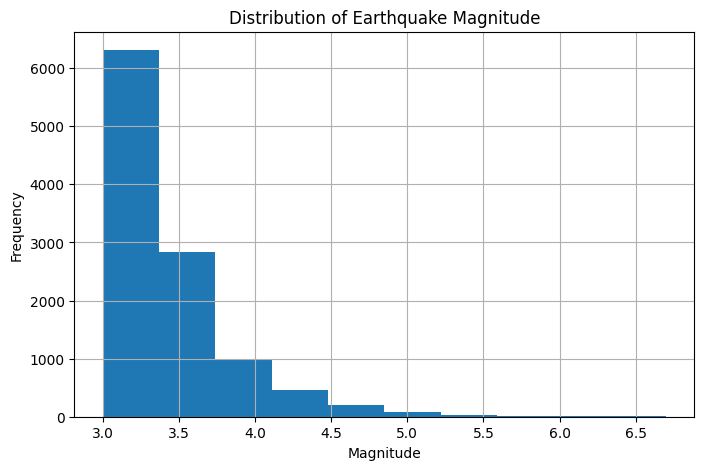

In [43]:
plt.figure(figsize=(8, 5))
df["mag"].hist()
plt.title("Distribution of Earthquake Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

According to the histogram, the distribution of earthquakes by magnitude shows a higher concentration of earthquakes at lower and medium magnitudes than there are at higher magnitudes. As you increase your magnitude, you will decrease how often you will see that magnitude. Therefore, there are generally less frequent large earthquakes in the data set compared to smaller earthquakes.

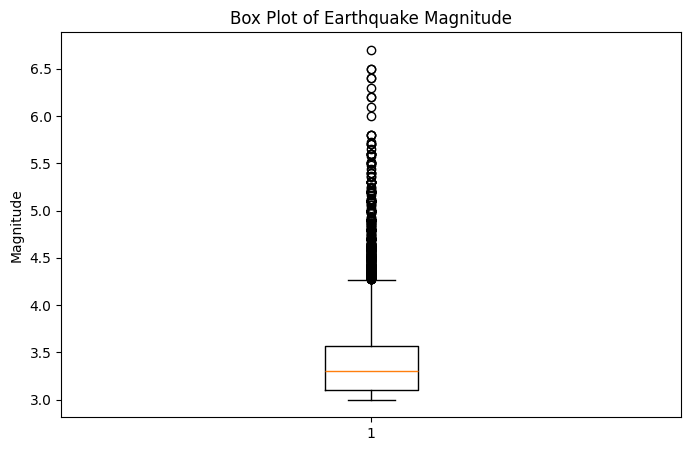

In [44]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["mag"].dropna())
plt.title("Box Plot of Earthquake Magnitude")
plt.ylabel("Magnitude")
plt.show()

The box plot indicates that a significant portion of the data's magnitude is concentrated within the center of the box, and the remaining values have a smaller quantity of values that are much greater than the values adjacent to them. The points located outside of the upper whiskers of the box plot show that their values are greater than the majority of the other Earthquake magnitude values, this indicates that there are some high magnitude earthquakes that are very different from the majority of the data values, supporting the idea that there are outliers in the dataset at the upper end of the magnitude values.

## Conclusion 

The distribution of the earthquake data indicates that most of the earthquakes in the dataset occurred within a much smaller range of magnitudes than those of the few that are clearly outside this scale. The greater the magnitude of an earthquake, the lower the occurrences.

The results of this distribution will be useful for understanding the general structure of one of the variable's primary characteristics within the dataset. Additionally, this example illustrates that extreme variations can often be found in other characteristics associated with both magnitude averages as well as variability, thus presenting a potential barrier when doing later analysis. 